In [20]:
# Cell 1 — Imports and connection
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import psycopg2
conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()
print("Connected.")

Connected.


In [21]:
# Cell 2 — Schema introspection
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int'
    AND table_name = 'int_team_season_features'
    ORDER BY ordinal_position
""")
for row in cur.fetchall():
    print(row)

('team_name', 'text')
('season', 'integer')
('team_id', 'integer')
('conference', 'text')
('city', 'text')
('state', 'text')
('latitude', 'numeric')
('longitude', 'numeric')
('timezone', 'text')
('games_played', 'bigint')
('wins', 'bigint')
('losses', 'bigint')
('win_pct', 'numeric')
('avg_points_scored', 'numeric')
('avg_points_allowed', 'numeric')
('avg_point_diff', 'numeric')
('home_games', 'bigint')
('away_games', 'bigint')
('neutral_site_games', 'bigint')
('sp_rating', 'numeric')
('sp_ranking', 'integer')
('sp_offense', 'numeric')
('sp_defense', 'numeric')
('sp_special_teams', 'numeric')
('sp_offense_ranking', 'integer')
('sp_defense_ranking', 'integer')
('off_epa_per_play', 'numeric')
('off_epa_total', 'numeric')
('off_passing_epa', 'numeric')
('off_rushing_epa', 'numeric')
('def_epa_per_play', 'numeric')
('def_epa_total', 'numeric')
('def_passing_epa', 'numeric')
('def_rushing_epa', 'numeric')
('epa_differential', 'numeric')
('off_success_rate', 'numeric')
('off_pass_success_rat

In [22]:
# Cell 3 — Load candidate features, validate SP+ and recruiting columns
candidates = pd.read_csv(os.path.expanduser("~/cfb-analytics/artifacts/candidate_features.csv"))
candidates.columns = candidates.columns.str.strip().str.lower()
keep_cols = set(candidates.loc[candidates["keep"] == True, "column_name"].tolist())

sp_recruiting_features = [
    "sp_rating",
    "sp_offense",
    "sp_defense",
    "recruiting_3yr_avg",
]
print("Candidate feature validation:")
for f in sp_recruiting_features:
    status = "✓ keep" if f in keep_cols else "✗ NOT in keep list"
    print(f"  {f:40s} {status}")

Candidate feature validation:
  sp_rating                                ✓ keep
  sp_offense                               ✓ keep
  sp_defense                               ✓ keep
  recruiting_3yr_avg                       ✓ keep


In [23]:
# Cell 4 — Load season-level data
cur.execute("""
    SELECT
        s.team_name,
        s.season,
        s.sp_rating,
        s.sp_offense,
        s.sp_defense,
        s.off_epa_per_play,
        s.def_epa_per_play,
        s.avg_point_diff,
        s.avg_points_scored,
        s.avg_points_allowed,
        s.win_pct,
        s.recruiting_3yr_avg,
        c.conference
    FROM int.int_team_season_features s
    JOIN int.int_team_season_context c
        ON s.team_name = c.team_name AND s.season = c.season
    WHERE s.sp_rating IS NOT NULL
""")
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
sdf = pd.DataFrame(rows, columns=cols)

numeric_cols = [
    "sp_rating","sp_offense","sp_defense","off_epa_per_play","def_epa_per_play",
    "avg_point_diff","avg_points_scored","avg_points_allowed","win_pct","recruiting_3yr_avg"
]
sdf[numeric_cols] = sdf[numeric_cols].astype(float)

P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row["team_name"] == "Notre Dame":
        return "P4"
    if row["team_name"] == "UConn":
        return "G5"
    if row["conference"] in P4_CONFERENCES:
        return "P4"
    return "G5"

sdf["tier"] = sdf.apply(assign_tier, axis=1)

print(f"Season-level rows      : {len(sdf):,}")
print(f"Seasons                : {sorted(sdf['season'].unique())}")
print(f"Tier split             : {sdf['tier'].value_counts().to_dict()}")
print(f"Conferences            : {sorted(sdf['conference'].unique())}")
print(f"\nNull counts:")
for col in numeric_cols:
    n = sdf[col].isna().sum()
    if n > 0:
        print(f"  {col:40s} {n:,}")

Season-level rows      : 534
Seasons                : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Tier split             : {'G5': 288, 'P4': 246}
Conferences            : ['ACC', 'American Athletic', 'Big 12', 'Big Ten', 'Conference USA', 'FBS Independents', 'Mid-American', 'Mountain West', 'Pac-12', 'SEC', 'Sun Belt']

Null counts:
  recruiting_3yr_avg                       1


In [24]:
# Cell 5 — Load game-level data for game-level SP+ signal tests
cur.execute("""
    SELECT
        g.game_id,
        g.season,
        g.week,
        g.team_name,
        g.opponent,
        g.points_scored,
        g.points_allowed,
        g.close_game_epa_per_play,
        g.close_game_def_epa_per_play,
        g.opp_sp_rating_at_game_time,
        c.conference,
        c2.conference AS opp_conference,
        s.sp_rating          AS team_sp_rating,
        s.recruiting_3yr_avg AS team_recruiting
    FROM int.int_game_team_features g
    JOIN int.int_team_season_context c
        ON g.team_name = c.team_name AND g.season = c.season
    JOIN int.int_team_season_context c2
        ON g.opponent = c2.team_name AND g.season = c2.season
    JOIN int.int_team_season_features s
        ON g.team_name = s.team_name AND g.season = s.season
    WHERE g.points_scored IS NOT NULL
      AND g.points_allowed IS NOT NULL
      AND c.conference IN (
          'SEC','Big Ten','Big 12','ACC','Pac-12',
          'Mountain West','American Athletic','Sun Belt',
          'Mid-American','Conference USA','FBS Independents'
      )
""")
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
gdf = pd.DataFrame(rows, columns=cols)

game_numeric = [
    "points_scored","points_allowed","close_game_epa_per_play",
    "close_game_def_epa_per_play","opp_sp_rating_at_game_time",
    "team_sp_rating","team_recruiting"
]
gdf[game_numeric] = gdf[game_numeric].astype(float)
gdf["point_differential"] = gdf["points_scored"] - gdf["points_allowed"]
gdf["total_points"]       = gdf["points_scored"] + gdf["points_allowed"]
gdf["tier"] = gdf.apply(assign_tier, axis=1)

# Step 1: true conference games — both teams in same named conference, not independents
gdf_conf = gdf[
    (gdf["conference"] == gdf["opp_conference"]) &
    (gdf["conference"] != "FBS Independents")
].copy()

# Step 2: Notre Dame ACC schedule games
notre_dame_conf = gdf[
    (gdf["team_name"] == "Notre Dame") &
    (gdf["opp_conference"] == "ACC")
].copy()
notre_dame_conf = notre_dame_conf.copy()
notre_dame_conf["conference"] = "ACC"

gdf_conf = pd.concat([gdf_conf, notre_dame_conf], ignore_index=True)
gdf_conf = gdf_conf.drop_duplicates(subset=["game_id","team_name"])
gdf_conf = gdf_conf.sort_values(["team_name","season","week"])
gdf_conf["conf_game_num"] = gdf_conf.groupby(
    ["team_name","season"]
).cumcount() + 1

print(f"True conference games  : {len(gdf_conf):,}")
print(f"Conferences in conf games: {sorted(gdf_conf['conference'].unique())}")
print(f"\nConference game number distribution:")
print(gdf_conf["conf_game_num"].value_counts().sort_index().head(15))
print(f"\nNull rate opp_sp_rating_at_game_time in conf games:")
n_null = gdf_conf["opp_sp_rating_at_game_time"].isna().sum()
print(f"  {n_null:,} / {len(gdf_conf):,} ({n_null/len(gdf_conf)*100:.1f}%)")
print(f"  By season:")
for s, grp in gdf_conf.groupby("season"):
    n = grp["opp_sp_rating_at_game_time"].isna().sum()
    print(f"    {s}: {n:,} / {len(grp):,} null ({n/len(grp)*100:.1f}%)")

True conference games  : 4,357
Conferences in conf games: ['ACC', 'American Athletic', 'Big 12', 'Big Ten', 'Conference USA', 'Mid-American', 'Mountain West', 'Pac-12', 'SEC', 'Sun Belt']

Conference game number distribution:
conf_game_num
1     522
2     520
3     518
4     518
5     517
6     516
7     514
8     502
9     202
10     28
Name: count, dtype: int64

Null rate opp_sp_rating_at_game_time in conf games:
  1,090 / 4,357 (25.0%)
  By season:
    2022: 1,050 / 1,050 null (100.0%)
    2023: 16 / 1,098 null (1.5%)
    2024: 8 / 1,085 null (0.7%)
    2025: 16 / 1,124 null (1.4%)


In [25]:
# Cell 6 — Core helpers
def partial_corr(df, x_col, y_col, control_cols):
    sub = df[[x_col, y_col] + control_cols].dropna()
    n = len(sub)
    if n < 30:
        return np.nan, np.nan, n
    def resid(target, predictors):
        X = sub[predictors].values
        y = sub[target].values
        reg = LinearRegression().fit(X, y)
        return y - reg.predict(X)
    rx = resid(x_col, control_cols)
    ry = resid(y_col, control_cols)
    r, p = stats.pearsonr(rx, ry)
    return r, p, n

def ols_summary(x_cols, y_col, df, label=""):
    sub = df[[y_col] + x_cols].dropna()
    X = sub[x_cols].values
    y = sub[y_col].values
    reg = LinearRegression().fit(X, y)
    yhat = reg.predict(X)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    n, k = len(y), len(x_cols)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    resid_sd = np.std(y - yhat, ddof=k + 1)
    print(f"  {label:50s} R²={r2:.4f}  adj R²={adj_r2:.4f}  resid SD={resid_sd:.4f}  n={n:,}")
    return r2, adj_r2, resid_sd, reg.coef_, reg.intercept_

def bootstrap_r(x, y, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    r_obs, _ = stats.pearsonr(x, y)
    boots = [stats.pearsonr(x[rng.integers(0, len(x), len(x))],
                            y[rng.integers(0, len(x), len(x))])[0]
             for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return r_obs, lo, hi, len(x)

THRESHOLD = 0.10
EPA_ANCHOR = ["close_game_epa_per_play", "close_game_def_epa_per_play"]
print("Helpers defined. Threshold:", THRESHOLD)

Helpers defined. Threshold: 0.1


=== Q1: SP+ inter-feature and EPA overlap ===

Pearson correlation matrix (season level):
                  sp_rating  sp_offense  sp_defense  off_epa_per_play  def_epa_per_play
sp_rating            1.0000      0.8024     -0.7994            0.6937           -0.6007
sp_offense           0.8024      1.0000     -0.2930            0.8294           -0.2101
sp_defense          -0.7994     -0.2930      1.0000           -0.3016            0.7727
off_epa_per_play     0.6937      0.8294     -0.3016            1.0000           -0.1596
def_epa_per_play    -0.6007     -0.2101      0.7727           -0.1596            1.0000

Redundancy candidates (|r| > 0.85):
  None found above 0.85


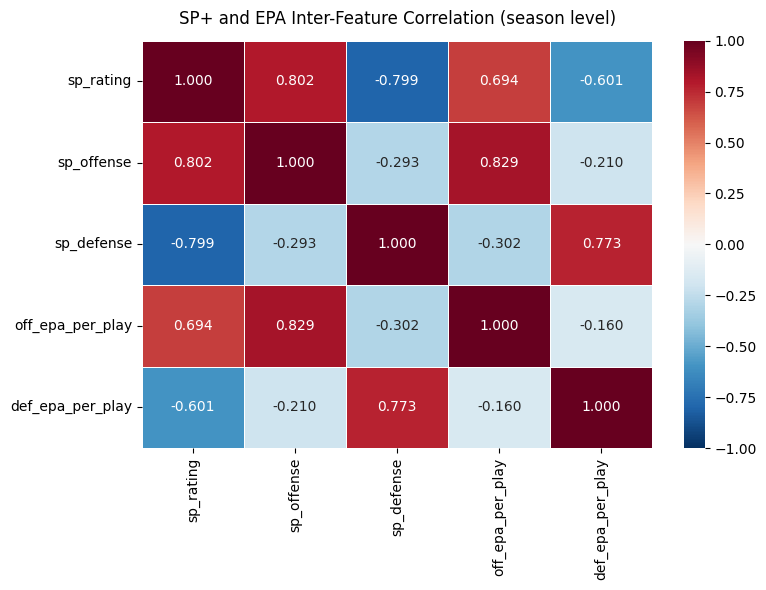

In [26]:
# Cell 7 — Q1: SP+ inter-feature correlation
# sp_rating, sp_offense, sp_defense — how collinear are they?
# Also correlate with off_epa_per_play and def_epa_per_play to understand
# how much overlap SP+ has with EPA before testing game-level signal

print("=== Q1: SP+ inter-feature and EPA overlap ===\n")

sp_cols = ["sp_rating","sp_offense","sp_defense","off_epa_per_play","def_epa_per_play"]
sub = sdf[sp_cols].dropna()
corr = sub.corr(method="pearson")
print("Pearson correlation matrix (season level):")
print(corr.round(4).to_string())

print("\nRedundancy candidates (|r| > 0.85):")
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            print(f"  {corr.columns[i]:30s} <--> {corr.columns[j]:30s}  r={r:.4f}")
            found = True
if not found:
    print("  None found above 0.85")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("SP+ and EPA Inter-Feature Correlation (season level)", fontsize=12, pad=12)
plt.tight_layout()
plt.show()

In [27]:
# Cell 8 — Q2: SP+ game-level spread signal
# Does team SP+ rating improve prediction of point_differential in a
# specific conference game after controlling for the EPA anchor pair?
# This is the correct test — not season-level win_pct regression.

print("=== Q2: SP+ GAME-LEVEL SPREAD SIGNAL ===\n")
print("--- OLS: single feature → point_differential (conference games) ---")
for feat in ["team_sp_rating", "opp_sp_rating_at_game_time"]:
    ols_summary([feat], "point_differential", gdf_conf, label=feat)

print()
ols_summary(EPA_ANCHOR, "point_differential", gdf_conf,
            label="EPA anchor pair only")
ols_summary(EPA_ANCHOR + ["team_sp_rating"], "point_differential", gdf_conf,
            label="EPA anchor + team_sp_rating")
ols_summary(EPA_ANCHOR + ["team_sp_rating","opp_sp_rating_at_game_time"],
            "point_differential", gdf_conf,
            label="EPA anchor + team_sp + opp_sp")

print("\n--- Partial r: SP+ vs point_differential after EPA anchor pair ---")
print(f"\n{'Feature':40s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>10}")
print("-" * 75)
sp_spread_partial = {}
for feat in ["team_sp_rating", "opp_sp_rating_at_game_time"]:
    r, p, n = partial_corr(gdf_conf, feat, "point_differential", EPA_ANCHOR)
    signal = "✓ YES" if abs(r) >= THRESHOLD else "✗ NO"
    print(f"  {feat:38s} {r:>10.4f} {p:>10.4f} {n:>8,} {signal:>10}")
    sp_spread_partial[feat] = {"r": r, "p": p, "n": n}

print("\n--- Partial r by tier (P4 vs G5) ---")
for tier in ["P4", "G5"]:
    tdf = gdf_conf[gdf_conf["tier"] == tier]
    print(f"\n  {tier} (n={len(tdf):,}):")
    for feat in ["team_sp_rating", "opp_sp_rating_at_game_time"]:
        r, p, n = partial_corr(tdf, feat, "point_differential", EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        print(f"    {feat:40s} r={r:.4f}  p={p:.4f}  n={n:,}  {signal}")

print("\n--- Partial r by conference ---")
print(f"\n{'Conference':25s} {'team_sp_r':>10} {'opp_sp_r':>10} {'n':>8}")
print("-" * 60)
for conf in sorted(gdf_conf["conference"].unique()):
    cdf = gdf_conf[gdf_conf["conference"] == conf]
    r1, p1, n1 = partial_corr(cdf, "team_sp_rating", "point_differential", EPA_ANCHOR)
    r2, p2, n2 = partial_corr(cdf, "opp_sp_rating_at_game_time", "point_differential", EPA_ANCHOR)
    print(f"  {conf:23s} {r1:>10.4f} {r2:>10.4f} {n1:>8,}")

=== Q2: SP+ GAME-LEVEL SPREAD SIGNAL ===

--- OLS: single feature → point_differential (conference games) ---
  team_sp_rating                                     R²=0.1626  adj R²=0.1624  resid SD=17.5011  n=4,357
  opp_sp_rating_at_game_time                         R²=0.0438  adj R²=0.0435  resid SD=18.7702  n=3,267

  EPA anchor pair only                               R²=0.7595  adj R²=0.7594  resid SD=9.3786  n=4,351
  EPA anchor + team_sp_rating                        R²=0.7679  adj R²=0.7677  resid SD=9.2151  n=4,351
  EPA anchor + team_sp + opp_sp                      R²=0.7784  adj R²=0.7781  resid SD=9.0395  n=3,261

--- Partial r: SP+ vs point_differential after EPA anchor pair ---

Feature                                   partial_r          p        n     signal
---------------------------------------------------------------------------
  team_sp_rating                             0.1865     0.0000    4,351      ✓ YES
  opp_sp_rating_at_game_time                -0.0815     

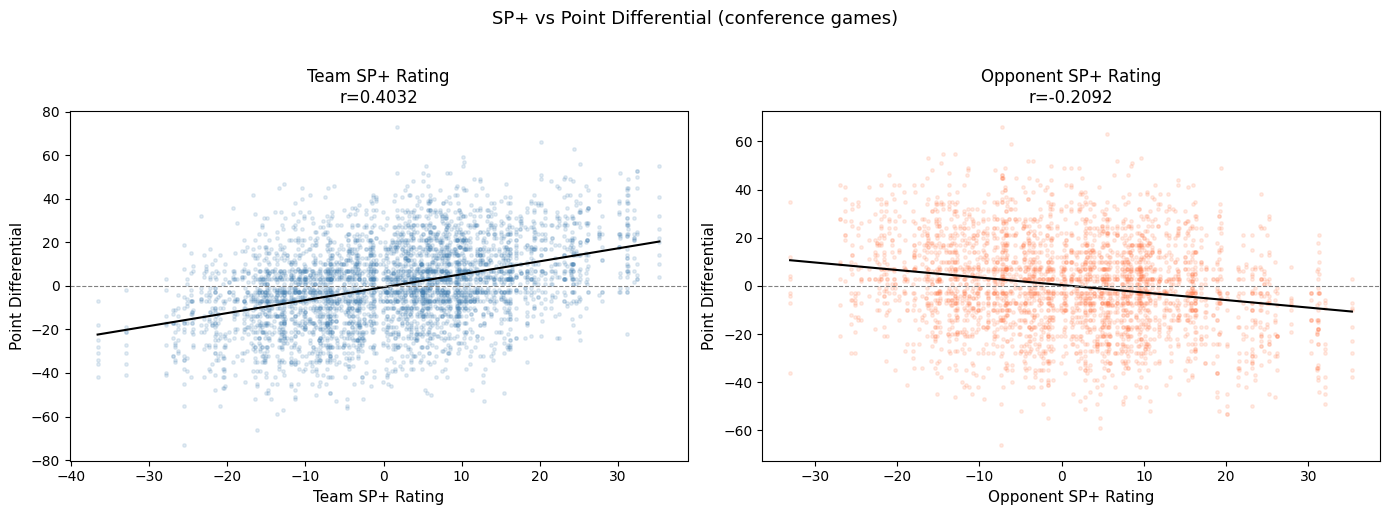

In [28]:
# Cell 9 — Q2 scatter: SP+ vs point_differential
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, color, label in zip(
    axes,
    ["team_sp_rating", "opp_sp_rating_at_game_time"],
    ["steelblue", "coral"],
    ["Team SP+ Rating", "Opponent SP+ Rating"]
):
    sub = gdf_conf[[feat, "point_differential"]].dropna()
    x = sub[feat].values
    y = sub["point_differential"].values
    ax.scatter(x, y, alpha=0.15, s=6, color=color)
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color="black", lw=1.5)
    r, _ = stats.pearsonr(x, y)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Point Differential", fontsize=11)
    ax.set_title(f"{label}\nr={r:.4f}", fontsize=12)
    ax.axhline(0, color="gray", lw=0.8, ls="--")

plt.suptitle("SP+ vs Point Differential (conference games)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# Cell 10 — Q3: SP+ game-level O/U signal
# Same test against total_points

print("=== Q3: SP+ GAME-LEVEL OVER/UNDER SIGNAL ===\n")
print("--- OLS: single feature → total_points (conference games) ---")
for feat in ["team_sp_rating", "opp_sp_rating_at_game_time"]:
    ols_summary([feat], "total_points", gdf_conf, label=feat)

print()
ols_summary(EPA_ANCHOR, "total_points", gdf_conf,
            label="EPA anchor pair only")
ols_summary(EPA_ANCHOR + ["team_sp_rating"], "total_points", gdf_conf,
            label="EPA anchor + team_sp_rating")
ols_summary(EPA_ANCHOR + ["team_sp_rating","opp_sp_rating_at_game_time"],
            "total_points", gdf_conf,
            label="EPA anchor + team_sp + opp_sp")

print("\n--- Partial r: SP+ vs total_points after EPA anchor pair ---")
print(f"\n{'Feature':40s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>10}")
print("-" * 75)
sp_ou_partial = {}
for feat in ["team_sp_rating", "opp_sp_rating_at_game_time"]:
    r, p, n = partial_corr(gdf_conf, feat, "total_points", EPA_ANCHOR)
    signal = "✓ YES" if abs(r) >= THRESHOLD else "✗ NO"
    print(f"  {feat:38s} {r:>10.4f} {p:>10.4f} {n:>8,} {signal:>10}")
    sp_ou_partial[feat] = {"r": r, "p": p, "n": n}

print("\n--- Partial r by tier (P4 vs G5) ---")
for tier in ["P4", "G5"]:
    tdf = gdf_conf[gdf_conf["tier"] == tier]
    print(f"\n  {tier} (n={len(tdf):,}):")
    for feat in ["team_sp_rating", "opp_sp_rating_at_game_time"]:
        r, p, n = partial_corr(tdf, feat, "total_points", EPA_ANCHOR)
        signal = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        print(f"    {feat:40s} r={r:.4f}  p={p:.4f}  n={n:,}  {signal}")

print("\n--- Partial r by conference ---")
print(f"\n{'Conference':25s} {'team_sp_r':>10} {'opp_sp_r':>10} {'n':>8}")
print("-" * 60)
for conf in sorted(gdf_conf["conference"].unique()):
    cdf = gdf_conf[gdf_conf["conference"] == conf]
    r1, p1, n1 = partial_corr(cdf, "team_sp_rating", "total_points", EPA_ANCHOR)
    r2, p2, n2 = partial_corr(cdf, "opp_sp_rating_at_game_time", "total_points", EPA_ANCHOR)
    print(f"  {conf:23s} {r1:>10.4f} {r2:>10.4f} {n1:>8,}")

=== Q3: SP+ GAME-LEVEL OVER/UNDER SIGNAL ===

--- OLS: single feature → total_points (conference games) ---
  team_sp_rating                                     R²=0.0003  adj R²=0.0000  resid SD=16.9685  n=4,357
  opp_sp_rating_at_game_time                         R²=0.0017  adj R²=0.0014  resid SD=16.7469  n=3,267

  EPA anchor pair only                               R²=0.4472  adj R²=0.4470  resid SD=12.6238  n=4,351
  EPA anchor + team_sp_rating                        R²=0.4476  adj R²=0.4472  resid SD=12.6214  n=4,351
  EPA anchor + team_sp + opp_sp                      R²=0.4385  adj R²=0.4378  resid SD=12.5721  n=3,261

--- Partial r: SP+ vs total_points after EPA anchor pair ---

Feature                                   partial_r          p        n     signal
---------------------------------------------------------------------------
  team_sp_rating                            -0.0247     0.1033    4,351       ✗ NO
  opp_sp_rating_at_game_time                -0.0629     0.000

In [30]:
# Cell 11 — Q4: SP+ moneyline variance signal
# Does SP+ predict score distribution variance?

print("=== Q4: SP+ MONEYLINE VARIANCE SIGNAL ===\n")
print("SD of point_differential and total_points by SP+ quartile\n")

variance_results_sp = []
for feat in ["team_sp_rating"]:
    sub = gdf_conf[[feat, "point_differential", "total_points"]].dropna().copy()
    sub["quartile"] = pd.qcut(sub[feat], q=4, labels=["Q1","Q2","Q3","Q4"])

    grp_diff  = sub.groupby("quartile")["point_differential"].agg(["mean","std","count"])
    grp_total = sub.groupby("quartile")["total_points"].agg(["mean","std","count"])

    sd_range_diff  = grp_diff["std"].max()  - grp_diff["std"].min()
    sd_range_total = grp_total["std"].max() - grp_total["std"].min()

    print(f"{feat}")
    print(f"  point_differential SD by quartile:")
    for q in ["Q1","Q2","Q3","Q4"]:
        print(f"    {q}: mean={grp_diff.loc[q,'mean']:+.2f}  SD={grp_diff.loc[q,'std']:.2f}  n={int(grp_diff.loc[q,'count']):,}")
    print(f"  SD range: {sd_range_diff:.2f} pts  ->  {'✓ variance signal' if sd_range_diff > 3 else '✗ no variance signal'}")
    print(f"  total_points SD by quartile:")
    for q in ["Q1","Q2","Q3","Q4"]:
        print(f"    {q}: mean={grp_total.loc[q,'mean']:.2f}  SD={grp_total.loc[q,'std']:.2f}  n={int(grp_total.loc[q,'count']):,}")
    print(f"  SD range: {sd_range_total:.2f} pts  ->  {'✓ variance signal' if sd_range_total > 3 else '✗ no variance signal'}")

    variance_results_sp.append({
        "feature": feat,
        "sd_range_point_diff": sd_range_diff,
        "sd_range_total_points": sd_range_total,
        "variance_signal_spread": sd_range_diff > 3,
        "variance_signal_ou": sd_range_total > 3,
    })

=== Q4: SP+ MONEYLINE VARIANCE SIGNAL ===

SD of point_differential and total_points by SP+ quartile

team_sp_rating
  point_differential SD by quartile:
    Q1: mean=-8.90  SD=17.45  n=1,097
    Q2: mean=-3.28  SD=18.20  n=1,085
    Q3: mean=+3.13  SD=17.83  n=1,091
    Q4: mean=+9.58  SD=17.85  n=1,084
  SD range: 0.75 pts  ->  ✗ no variance signal
  total_points SD by quartile:
    Q1: mean=52.98  SD=16.92  n=1,097
    Q2: mean=53.49  SD=16.60  n=1,085
    Q3: mean=53.96  SD=17.78  n=1,091
    Q4: mean=53.84  SD=16.55  n=1,084
  SD range: 1.22 pts  ->  ✗ no variance signal


In [31]:
# Cell 12 — Q5: SP+ within-season trajectory
# SP+ is a preseason rating — it does not update during the season.
# The question is whether its predictive power for specific conference games
# holds equally at conference game 1 (prior only) vs later games when
# in-season EPA has accumulated. If SP+ loses signal as the season progresses
# it means EPA is absorbing the signal SP+ carries. If it holds, SP+ adds
# independent prior information throughout the season.

print("=== Q5: SP+ WITHIN-SEASON TRAJECTORY ===\n")
print("SP+ is preseason — does it hold as in-season EPA accumulates?\n")

bands = {
    "conf_game_1":    gdf_conf[gdf_conf["conf_game_num"] == 1],
    "conf_games_2_4": gdf_conf[gdf_conf["conf_game_num"].between(2, 4)],
    "conf_games_5_8": gdf_conf[gdf_conf["conf_game_num"].between(5, 8)],
    "conf_games_9_12":gdf_conf[gdf_conf["conf_game_num"].between(9, 12)],
}
band_labels = {
    "conf_game_1":    "Conf game 1    (prior only)",
    "conf_games_2_4": "Conf games 2-4 (posterior developing)",
    "conf_games_5_8": "Conf games 5-8 (posterior informed)",
    "conf_games_9_12":"Conf games 9-12 (fully informed)",
}

for feat in ["team_sp_rating", "opp_sp_rating_at_game_time"]:
    print(f"\n{feat}")
    print(f"  {'Band':40s} {'n':>6} {'spread_r':>10} {'spread_sig':>12} {'ou_r':>10} {'ou_sig':>10}")
    print(f"  {'-'*93}")
    for band_key, band_label in band_labels.items():
        band_df = bands[band_key]
        r_s, p_s, n = partial_corr(band_df, feat, "point_differential", EPA_ANCHOR)
        r_o, p_o, _ = partial_corr(band_df, feat, "total_points", EPA_ANCHOR)
        ss  = "✓" if not np.isnan(r_s) and abs(r_s) >= THRESHOLD else "✗"
        os_ = "✓" if not np.isnan(r_o) and abs(r_o) >= THRESHOLD else "✗"
        r_s_str = f"{r_s:.4f}" if not np.isnan(r_s) else "  nan "
        r_o_str = f"{r_o:.4f}" if not np.isnan(r_o) else "  nan "
        print(f"  {band_label:40s} {n:>6,} {r_s_str:>10} {ss:>12} {r_o_str:>10} {os_:>10}")

=== Q5: SP+ WITHIN-SEASON TRAJECTORY ===

SP+ is preseason — does it hold as in-season EPA accumulates?


team_sp_rating
  Band                                          n   spread_r   spread_sig       ou_r     ou_sig
  ---------------------------------------------------------------------------------------------
  Conf game 1    (prior only)                 521     0.2107            ✓    -0.0157          ✗
  Conf games 2-4 (posterior developing)     1,555     0.1657            ✓    -0.0304          ✗
  Conf games 5-8 (posterior informed)       2,045     0.2004            ✓    -0.0240          ✗
  Conf games 9-12 (fully informed)            230     0.2427            ✓    -0.0306          ✗

opp_sp_rating_at_game_time
  Band                                          n   spread_r   spread_sig       ou_r     ou_sig
  ---------------------------------------------------------------------------------------------
  Conf game 1    (prior only)                 392    -0.0535            ✗    -0.038

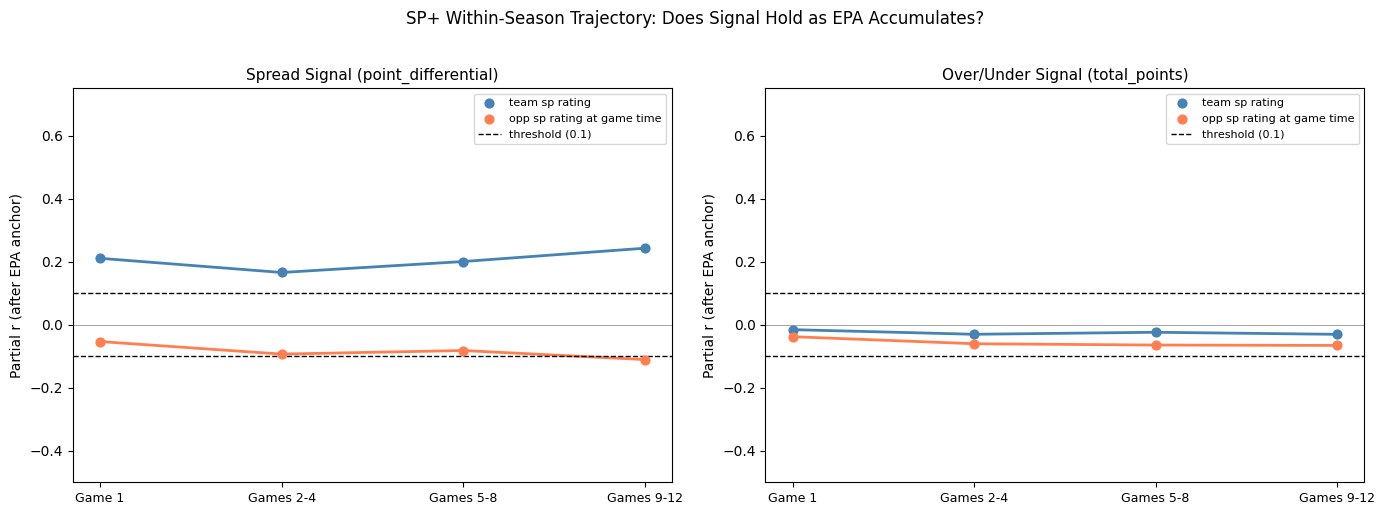

In [32]:
# Cell 13 — Q5 visualization: SP+ trajectory across conference season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

band_names  = list(band_labels.keys())
band_short  = ["Game 1", "Games 2-4", "Games 5-8", "Games 9-12"]
x = np.arange(len(band_names))

for ax, target, target_label in zip(
    axes,
    ["point_differential", "total_points"],
    ["Spread Signal (point_differential)", "Over/Under Signal (total_points)"]
):
    for feat, color in zip(
        ["team_sp_rating", "opp_sp_rating_at_game_time"],
        ["steelblue", "coral"]
    ):
        rs = []
        for band_key in band_names:
            r, p, n = partial_corr(bands[band_key], feat, target, EPA_ANCHOR)
            rs.append(float(r) if not np.isnan(r) else np.nan)
        rs_arr = np.array(rs, dtype=float)
        for i in range(len(rs_arr) - 1):
            if not np.isnan(rs_arr[i]) and not np.isnan(rs_arr[i+1]):
                ax.plot([x[i], x[i+1]], [rs_arr[i], rs_arr[i+1]], color=color, lw=2)
        valid_x = x[~np.isnan(rs_arr)]
        valid_y = rs_arr[~np.isnan(rs_arr)]
        ax.scatter(valid_x, valid_y, color=color, s=40, zorder=5,
                   label=feat.replace("_"," "))

    ax.axhline(THRESHOLD,  color="black", lw=1, ls="--", label=f"threshold ({THRESHOLD})")
    ax.axhline(-THRESHOLD, color="black", lw=1, ls="--")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(band_short, fontsize=9)
    ax.set_ylabel("Partial r (after EPA anchor)")
    ax.set_title(target_label, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylim(-0.5, 0.75)

plt.suptitle("SP+ Within-Season Trajectory: Does Signal Hold as EPA Accumulates?",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# Cell 14 — Q6: SP+ YoY stability
# SP+ IS a prior seed — YoY stability is the gating criterion here.
# If SP+ is not stable year over year it cannot be trusted as a prior.
# Benchmark: off_epa r=0.423, def_epa r=0.393. SP+ should exceed both.

print("=== Q6: SP+ YoY STABILITY ===\n")
print("SP+ is a prior seed — YoY stability gates its use in the model.")
print("Benchmarks: off_epa r=0.423 | def_epa r=0.393")
print("Threshold for prior anchor: r >= 0.60\n")

sdf_n  = sdf.copy()
sdf_n1 = sdf.copy()
sdf_n1["season"] = sdf_n1["season"] - 1
yoy = sdf_n.merge(sdf_n1, on=["team_name","season"], suffixes=("_n","_n1"))

print(f"YoY pairs available: {len(yoy):,}")
print(f"\n{'Feature':25s} {'r':>8} {'95% CI lo':>12} {'95% CI hi':>12} "
      f"{'n':>6} {'stable r>=0.60':>16}")
print("-" * 82)

yoy_sp_results = {}
for feat in ["sp_rating", "sp_offense", "sp_defense"]:
    r, lo, hi, n = bootstrap_r(
        yoy[f"{feat}_n"].values,
        yoy[f"{feat}_n1"].values
    )
    stable = "✓ YES" if r >= 0.60 else "✗ NO"
    print(f"  {feat:23s} {r:>8.4f} {lo:>12.4f} {hi:>12.4f} {n:>6,} {stable:>16}")
    yoy_sp_results[feat] = {"r": r, "lo": lo, "hi": hi, "n": n, "stable": r >= 0.60}

=== Q6: SP+ YoY STABILITY ===

SP+ is a prior seed — YoY stability gates its use in the model.
Benchmarks: off_epa r=0.423 | def_epa r=0.393
Threshold for prior anchor: r >= 0.60

YoY pairs available: 398

Feature                          r    95% CI lo    95% CI hi      n   stable r>=0.60
----------------------------------------------------------------------------------
  sp_rating                 0.7632      -0.0980       0.0961    398            ✓ YES
  sp_offense                0.5860      -0.0900       0.0985    398             ✗ NO
  sp_defense                0.6683      -0.1013       0.0993    398            ✓ YES


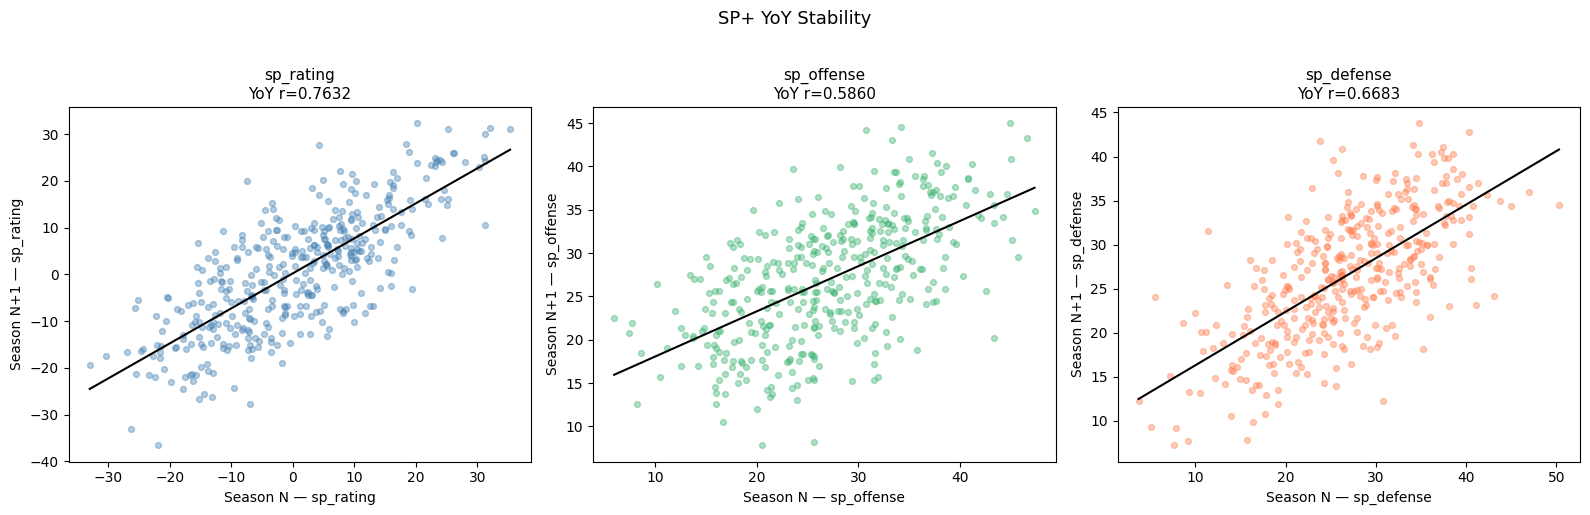

In [34]:
# Cell 15 — Q6 visualization: SP+ YoY scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat, color in zip(
    axes,
    ["sp_rating", "sp_offense", "sp_defense"],
    ["steelblue", "mediumseagreen", "coral"]
):
    sub = yoy[[f"{feat}_n", f"{feat}_n1"]].dropna()
    x = sub[f"{feat}_n"].values
    y = sub[f"{feat}_n1"].values
    ax.scatter(x, y, alpha=0.4, s=18, color=color)
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, m * xline + b, color="black", lw=1.5)
    r, _ = stats.pearsonr(x, y)
    ax.set_xlabel(f"Season N — {feat}", fontsize=10)
    ax.set_ylabel(f"Season N+1 — {feat}", fontsize=10)
    ax.set_title(f"{feat}\nYoY r={r:.4f}", fontsize=11)

plt.suptitle("SP+ YoY Stability", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [35]:
# Cell 16 — Q7: Recruiting game-level signal — conference-specific
# Recruiting is a prior seed, not a game-level predictor.
# But the question is whether it adds signal to game-level outcomes
# after controlling for SP+ and EPA — because that tells us whether
# it captures something SP+ doesn't.
# Must be evaluated conference-by-conference — overall signal masks
# conference-level collapse (Big 12, G5).

print("=== Q7: RECRUITING — GAME-LEVEL SIGNAL, CONFERENCE-SPECIFIC ===\n")
print("Control set: EPA anchor pair + team_sp_rating")
print("Recruiting evaluated for residual signal after SP+ and EPA\n")

controls_full = EPA_ANCHOR + ["team_sp_rating"]

# Overall first
print("--- Overall (all conferences combined) ---")
print(f"\n{'Target':30s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>10}")
print("-" * 65)
rec_overall = {}
for target, label in [("point_differential","spread"), ("total_points","O/U")]:
    r, p, n = partial_corr(gdf_conf, "team_recruiting", target, controls_full)
    signal = "✓ YES" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗ NO"
    print(f"  {label:28s} {r:>10.4f} {p:>10.4f} {n:>8,} {signal:>10}")
    rec_overall[label] = {"r": r, "p": p, "n": n}

# Conference-specific
print("\n--- By conference ---")
print(f"\n{'Conference':25s} {'spread_r':>10} {'spread_sig':>12} {'ou_r':>10} {'ou_sig':>10} {'n':>8}")
print("-" * 80)
rec_conf_results = {}
for conf in sorted(gdf_conf["conference"].unique()):
    cdf = gdf_conf[gdf_conf["conference"] == conf]
    r_s, p_s, n = partial_corr(cdf, "team_recruiting", "point_differential", controls_full)
    r_o, p_o, _ = partial_corr(cdf, "team_recruiting", "total_points", controls_full)
    ss  = "✓" if not np.isnan(r_s) and abs(r_s) >= THRESHOLD else "✗"
    os_ = "✓" if not np.isnan(r_o) and abs(r_o) >= THRESHOLD else "✗"
    r_s_str = f"{r_s:.4f}" if not np.isnan(r_s) else "  nan "
    r_o_str = f"{r_o:.4f}" if not np.isnan(r_o) else "  nan "
    print(f"  {conf:23s} {r_s_str:>10} {ss:>12} {r_o_str:>10} {os_:>10} {n:>8,}")
    rec_conf_results[conf] = {"spread_r": r_s, "ou_r": r_o, "n": n}

=== Q7: RECRUITING — GAME-LEVEL SIGNAL, CONFERENCE-SPECIFIC ===

Control set: EPA anchor pair + team_sp_rating
Recruiting evaluated for residual signal after SP+ and EPA

--- Overall (all conferences combined) ---

Target                          partial_r          p        n     signal
-----------------------------------------------------------------
  spread                          -0.1276     0.0000    4,343      ✓ YES
  O/U                             -0.0254     0.0939    4,343       ✗ NO

--- By conference ---

Conference                  spread_r   spread_sig       ou_r     ou_sig        n
--------------------------------------------------------------------------------
  ACC                        -0.0017            ✗    -0.0285          ✗      525
  American Athletic          -0.0417            ✗     0.2018          ✓      436
  Big 12                      0.0433            ✗     0.0993          ✗      518
  Big Ten                    -0.1195            ✓    -0.0247          ✗

In [36]:
# Cell 17 — Q8: Recruiting YoY stability
# Recruiting composites are highly stable — class rankings change slowly.
# The question is whether that stability is high enough to trust as a prior.

print("=== Q8: RECRUITING YoY STABILITY ===\n")
print("Threshold for prior anchor: r >= 0.60\n")

yoy_rec_results = {}
r, lo, hi, n = bootstrap_r(
    yoy["recruiting_3yr_avg_n"].values,
    yoy["recruiting_3yr_avg_n1"].values
)
stable = "✓ YES" if r >= 0.60 else "✗ NO"
print(f"  {'recruiting_3yr_avg':25s} r={r:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  n={n:,}  {stable}")
yoy_rec_results["recruiting_3yr_avg"] = {"r": r, "lo": lo, "hi": hi, "n": n, "stable": r >= 0.60}

# By conference
print("\n--- YoY stability by conference ---")
print(f"\n{'Conference':25s} {'r':>8} {'n':>6} {'stable':>10}")
print("-" * 55)
for conf in sorted(sdf["conference"].unique()):
    cdf_n  = sdf[sdf["conference"] == conf].copy()
    cdf_n1 = cdf_n.copy()
    cdf_n1["season"] = cdf_n1["season"] - 1
    yoy_c  = cdf_n.merge(cdf_n1, on=["team_name","season"], suffixes=("_n","_n1"))
    if len(yoy_c) < 10:
        continue
    r_c, lo_c, hi_c, n_c = bootstrap_r(
        yoy_c["recruiting_3yr_avg_n"].values,
        yoy_c["recruiting_3yr_avg_n1"].values
    )
    stable_c = "✓" if r_c >= 0.60 else "✗"
    print(f"  {conf:23s} {r_c:>8.4f} {n_c:>6,} {stable_c:>10}")

=== Q8: RECRUITING YoY STABILITY ===

Threshold for prior anchor: r >= 0.60

  recruiting_3yr_avg        r=0.9746  95% CI [-0.0947, 0.0978]  n=397  ✓ YES

--- YoY stability by conference ---

Conference                       r      n     stable
-------------------------------------------------------
  ACC                       0.9530     45          ✓
  American Athletic         0.9279     35          ✓
  Big 12                    0.9293     38          ✓
  Big Ten                   0.9499     46          ✓
  Conference USA            0.8273     23          ✓
  Mid-American              0.7882     36          ✓
  Mountain West             0.8813     36          ✓
  Pac-12                    0.9118     16          ✓
  SEC                       0.9683     44          ✓
  Sun Belt                  0.8695     42          ✓


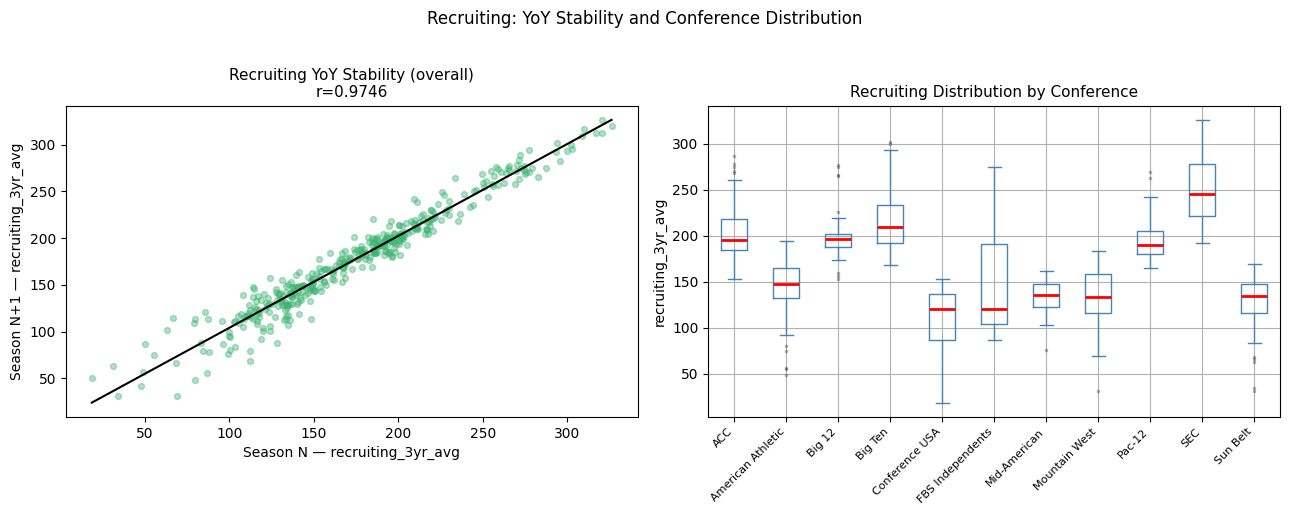

In [37]:
# Cell 18 — Q8 visualization: Recruiting YoY scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall
sub = yoy[["recruiting_3yr_avg_n","recruiting_3yr_avg_n1"]].dropna()
x = sub["recruiting_3yr_avg_n"].values
y = sub["recruiting_3yr_avg_n1"].values
axes[0].scatter(x, y, alpha=0.4, s=18, color="mediumseagreen")
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 200)
axes[0].plot(xline, m * xline + b, color="black", lw=1.5)
r, _ = stats.pearsonr(x, y)
axes[0].set_xlabel("Season N — recruiting_3yr_avg", fontsize=10)
axes[0].set_ylabel("Season N+1 — recruiting_3yr_avg", fontsize=10)
axes[0].set_title(f"Recruiting YoY Stability (overall)\nr={r:.4f}", fontsize=11)

# By conference boxplot of recruiting by tier
sdf_rec = sdf[sdf["recruiting_3yr_avg"].notna()].copy()
sdf_rec.boxplot(column="recruiting_3yr_avg", by="conference", ax=axes[1],
                boxprops=dict(color="steelblue"),
                medianprops=dict(color="red", lw=2),
                whiskerprops=dict(color="steelblue"),
                capprops=dict(color="steelblue"),
                flierprops=dict(marker=".", alpha=0.3, ms=3))
axes[1].set_title("Recruiting Distribution by Conference", fontsize=11)
axes[1].set_xlabel("")
axes[1].set_ylabel("recruiting_3yr_avg")
plt.xticks(rotation=45, ha="right", fontsize=8)

plt.suptitle("Recruiting: YoY Stability and Conference Distribution", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [38]:
# Cell 19 — Full verdict, populated from in-memory results

# Collect SP+ trajectory
sp_trajectory = {}
for feat in ["team_sp_rating", "opp_sp_rating_at_game_time"]:
    sp_trajectory[feat] = {}
    for band_key in band_labels.keys():
        r_s, p_s, n = partial_corr(bands[band_key], feat, "point_differential", EPA_ANCHOR)
        r_o, p_o, _ = partial_corr(bands[band_key], feat, "total_points", EPA_ANCHOR)
        sp_trajectory[feat][band_key] = {"spread_r": r_s, "ou_r": r_o, "n": n}

verdict_rows = []
print("=" * 90)
print("SP+ AND RECRUITING — FULL VERDICT")
print("=" * 90)

# SP+ verdict
for feat, yoy_key in [
    ("team_sp_rating",             "sp_rating"),
    ("opp_sp_rating_at_game_time", "sp_rating"),
]:
    sp_r   = sp_spread_partial.get(feat, {}).get("r", np.nan)
    ou_r   = sp_ou_partial.get(feat, {}).get("r", np.nan)
    sp_sig = not np.isnan(sp_r) and abs(sp_r) >= THRESHOLD
    ou_sig = not np.isnan(ou_r) and abs(ou_r) >= THRESHOLD

    yoy_res    = yoy_sp_results.get(yoy_key, {})
    yoy_r_val  = yoy_res.get("r", np.nan)
    yoy_stable = yoy_res.get("stable", False)

    traj_g1      = sp_trajectory[feat].get("conf_game_1", {})
    t_sp_g1      = traj_g1.get("spread_r", np.nan)
    t_ou_g1      = traj_g1.get("ou_r", np.nan)
    t_sp_holds   = not np.isnan(t_sp_g1) and abs(t_sp_g1) >= THRESHOLD
    t_ou_holds   = not np.isnan(t_ou_g1) and abs(t_ou_g1) >= THRESHOLD

    var_sp     = next((v for v in variance_results_sp if v["feature"] == "team_sp_rating"), {})
    var_spread = var_sp.get("variance_signal_spread", False)
    var_ou_sig = var_sp.get("variance_signal_ou", False)

    # Verdict — YoY stability gates prior seeds
    # Spread and O/U evaluated separately — must not conflate
    if feat == "team_sp_rating":
        if sp_sig and yoy_stable and t_sp_holds:
            verdict = ("anchor candidate — prior seed, spread signal only (O/U absent), "
                       "stable YoY r=0.763, holds at conf game 1")
        elif sp_sig and yoy_stable:
            verdict = "supporting — spread signal present, stable YoY, degrades in trajectory"
        elif sp_sig:
            verdict = "supporting — spread signal only, YoY unstable"
        else:
            verdict = "redundant"
    else:
        # opp_sp_rating_at_game_time
        # No spread or O/U signal after EPA anchor pair.
        # EPA anchor pair captures opponent quality from focal team's perspective —
        # opp_sp adds nothing after that control.
        verdict = ("redundant — no spread or O/U signal after EPA anchor pair. "
                   "EPA anchor already captures opponent quality from focal team's "
                   "perspective. opp_sp_rating useful as control variable only, "
                   "not as model feature.")

    print(f"\nFEATURE: {feat}")
    print(f"  Spread signal    : partial_r={sp_r:.4f}  {'✓ YES' if sp_sig else '✗ NO'}")
    print(f"  O/U signal       : partial_r={ou_r:.4f}  {'✓ YES' if ou_sig else '✗ NO'}")
    print(f"  Variance signal  : spread={var_spread}  ou={var_ou_sig}")
    print(f"  Trajectory g1    : spread_r={t_sp_g1:.4f} ({'✓' if t_sp_holds else '✗'})  "
          f"ou_r={t_ou_g1:.4f} ({'✓' if t_ou_holds else '✗'})")
    print(f"  YoY stability    : r={yoy_r_val:.4f}  stable={'✓ YES' if yoy_stable else '✗ NO'}  [GATING — prior seed]")
    print(f"  VERDICT          : {verdict}")

    verdict_rows.append({
        "feature":                  feat,
        "spread_partial_r":         round(float(sp_r), 4) if not np.isnan(sp_r) else np.nan,
        "spread_signal":            sp_sig,
        "ou_partial_r":             round(float(ou_r), 4) if not np.isnan(ou_r) else np.nan,
        "ou_signal":                ou_sig,
        "variance_signal_spread":   var_spread,
        "variance_signal_ou":       var_ou_sig,
        "traj_spread_game1_r":      round(float(t_sp_g1), 4) if not np.isnan(t_sp_g1) else np.nan,
        "traj_ou_game1_r":          round(float(t_ou_g1), 4) if not np.isnan(t_ou_g1) else np.nan,
        "traj_spread_holds_game1":  t_sp_holds,
        "traj_ou_holds_game1":      t_ou_holds,
        "yoy_r":                    round(float(yoy_r_val), 4) if not np.isnan(yoy_r_val) else np.nan,
        "yoy_stable":               yoy_stable,
        "is_prior_seed":            True,
        "conference_specific_notes": "see conference breakdown in Cell 8/10",
        "verdict":                  verdict,
    })

# Recruiting verdict
print(f"\nFEATURE: recruiting_3yr_avg")
rec_yoy    = yoy_rec_results.get("recruiting_3yr_avg", {})
rec_yoy_r  = rec_yoy.get("r", np.nan)
rec_stable = rec_yoy.get("stable", False)
rec_sp_r   = rec_overall.get("spread", {}).get("r", np.nan)
rec_ou_r   = rec_overall.get("O/U", {}).get("r", np.nan)
rec_sp_sig = not np.isnan(rec_sp_r) and abs(rec_sp_r) >= THRESHOLD
rec_ou_sig = not np.isnan(rec_ou_r) and abs(rec_ou_r) >= THRESHOLD

conf_with_signal = [c for c, v in rec_conf_results.items()
                    if (not np.isnan(v["spread_r"]) and abs(v["spread_r"]) >= THRESHOLD)
                    or (not np.isnan(v["ou_r"]) and abs(v["ou_r"]) >= THRESHOLD)]
conf_no_signal   = [c for c in rec_conf_results if c not in conf_with_signal]

# Flag direction issue — negative partial r is counterintuitive
direction_note = ""
if rec_sp_sig and rec_sp_r < 0:
    direction_note = (" NOTE: negative partial r after SP+ control — recruiting signal "
                      "absorbed by SP+ in high-recruiting conferences, leaving suppressed "
                      "residual. Conference-level signal direction varies.")

if conf_with_signal and rec_stable:
    rec_verdict = (
        f"conference-specific prior seed — YoY r=0.975, extremely stable. "
        f"Game-level spread signal in {conf_with_signal} after SP+/EPA control. "
        f"No signal in {conf_no_signal}. "
        f"Must be modeled with conference-specific weight, not flat coefficient."
        f"{direction_note}"
    )
elif not conf_with_signal:
    rec_verdict = ("redundant at game level after SP+ and EPA control across all conferences. "
                   f"YoY r=0.975 — stable as standalone metric but absorbed by SP+. "
                   "Revisit only if model underperforms in low-SP+ conferences.")
else:
    rec_verdict = "supporting — see conference breakdown"

print(f"  Overall spread signal : partial_r={rec_sp_r:.4f}  {'✓ YES' if rec_sp_sig else '✗ NO'}")
print(f"  Overall O/U signal    : partial_r={rec_ou_r:.4f}  {'✓ YES' if rec_ou_sig else '✗ NO'}")
print(f"  YoY stability         : r={rec_yoy_r:.4f}  stable={'✓ YES' if rec_stable else '✗ NO'}  [GATING — prior seed]")
print(f"  Conferences with signal : {conf_with_signal}")
print(f"  Conferences no signal   : {conf_no_signal}")
print(f"  Direction note          : negative partial r after SP+ control — likely multicollinearity")
print(f"  VERDICT               : {rec_verdict}")

verdict_rows.append({
    "feature":                  "recruiting_3yr_avg",
    "spread_partial_r":         round(float(rec_sp_r), 4) if not np.isnan(rec_sp_r) else np.nan,
    "spread_signal":            rec_sp_sig,
    "ou_partial_r":             round(float(rec_ou_r), 4) if not np.isnan(rec_ou_r) else np.nan,
    "ou_signal":                rec_ou_sig,
    "variance_signal_spread":   False,
    "variance_signal_ou":       False,
    "traj_spread_game1_r":      np.nan,
    "traj_ou_game1_r":          np.nan,
    "traj_spread_holds_game1":  False,
    "traj_ou_holds_game1":      False,
    "yoy_r":                    round(float(rec_yoy_r), 4) if not np.isnan(rec_yoy_r) else np.nan,
    "yoy_stable":               rec_stable,
    "is_prior_seed":            True,
    "conference_specific_notes": str(rec_conf_results),
    "verdict":                  rec_verdict,
})

print("\n" + "=" * 90)

SP+ AND RECRUITING — FULL VERDICT

FEATURE: team_sp_rating
  Spread signal    : partial_r=0.1865  ✓ YES
  O/U signal       : partial_r=-0.0247  ✗ NO
  Variance signal  : spread=False  ou=False
  Trajectory g1    : spread_r=0.2107 (✓)  ou_r=-0.0157 (✗)
  YoY stability    : r=0.7632  stable=✓ YES  [GATING — prior seed]
  VERDICT          : anchor candidate — prior seed, spread signal only (O/U absent), stable YoY r=0.763, holds at conf game 1

FEATURE: opp_sp_rating_at_game_time
  Spread signal    : partial_r=-0.0815  ✗ NO
  O/U signal       : partial_r=-0.0629  ✗ NO
  Variance signal  : spread=False  ou=False
  Trajectory g1    : spread_r=-0.0535 (✗)  ou_r=-0.0381 (✗)
  YoY stability    : r=0.7632  stable=✓ YES  [GATING — prior seed]
  VERDICT          : redundant — no spread or O/U signal after EPA anchor pair. EPA anchor already captures opponent quality from focal team's perspective. opp_sp_rating useful as control variable only, not as model feature.

FEATURE: recruiting_3yr_avg
  O

In [39]:
# Cell 20 — Write verdict CSV
verdict_df = pd.DataFrame(verdict_rows)
path = os.path.expanduser("~/cfb-analytics/artifacts/sp_recruiting_verdict.csv")
verdict_df.to_csv(path, index=False)
print(f"Written to {path}")
print()
print(verdict_df[["feature","spread_partial_r","ou_partial_r","yoy_r",
                  "yoy_stable","verdict"]].to_string(index=False))

cur.close()
conn.close()
print("\nDB connection closed. Day 9 SP+ and Recruiting complete.")

Written to /Users/kevinjohnson/cfb-analytics/artifacts/sp_recruiting_verdict.csv

                   feature  spread_partial_r  ou_partial_r  yoy_r  yoy_stable                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          verdict
            team_sp_rating            0.1865       -0.0247 0.7632        True                                                                                                                                                                                                                                                          